# 21 - Reproductive-concentration structures simulated (E27, H208-H212)

**Author**: kj  **Approach**: model-as-judge, per the canonical testing protocol

A deliberately far-fetched, controversial fanout: does concentrating reproduction on one sex move
fertility? The model does not care about taboo - only about the channel arithmetic. Concentration trades a
female-side childlessness / parity effect against a coupling effect through the *excluded* sex, and because
`TFR = C·(1-ρ)·P̄·fec(τ)·(1-kBF·dτ)` is multiplicative with C a leading, bistable factor, a moderate
excluded-sex drag on C can zero out any within-marriage P̄ gain.

The arc covers both sides and the state/media variants:

- **H208** - polygyny (one male, many females): male-concentrated reproduction
- **H209** - polyandry (one female, many males): female-side concentration
- **H210** - extreme hypergamy / mating-market skew (top-male concentration without an institution)
- **H211** - state-sanctioned vs outlawed concentration
- **H212** - media / normalisation forcing on the norm state N

The evidence (digest in `references/papers/e27-concentration-structures-digest.md`) says the excluded-sex
externality on C dominates in a developed low-fertility society, and the only structure that reliably moves
TFR (polyandry) moves it the WRONG way. This notebook tests that against the calibrated model on the
Korea / Germany / France triad.

**Output**: `reports/figures/nb21_concentration_sim.png`, `reports/nb21_e27_verdicts.json`,
`reports/nb21_concentration_table.csv`. Campaign total 232 -> 237 (after E26).

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration and the coupled model

Imports the coupled model from the library (`sci_demographic_collapse.emergent`), including the bistable
norm state N (E25). Concentration structures are mapped onto the channels they actually move: a within-
marriage parity effect (`fPb`), a female-childlessness effect (`fRV`, signed by which sex is concentrated),
the excluded-sex externality on coupling and security (`fC`, `fS`), a tempo delay (`fTau`), and a norm /
media forcing (`fN`).

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]; C_THR=PARAMS["C_thr"]
BASE={reg:m.run(reg) for reg in TRIAD}
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]
    if dtfr<-0.02: fate="deepens"
    elif t["tfr"]>1.5 and t["Cend"]>C_THR: fate="recovers"
    elif dtfr>0.10: fate="bends"
    else: fate="holds"
    return dict(dtfr=dtfr,fate=fate,tfr=t["tfr"],Cend=t["Cend"],traj=t)
def force_of(levers,start=0):
    if isinstance(levers,dict): levers=[levers]
    idx={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5}
    def fy(yr):
        f=[0.]*6
        for L in levers:
            s=L["mag"]*ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))*(1-L.get("delta",0.0))
            for k,v in L["f"].items(): f[idx[k]]+=v*s
        return f
    return fy
def cost(L): return round(0.40*L["fi"]+0.35*L["co"]+0.25*L["si"],3)
rprint("[green]library coupled model ready; concentration arc on the triad[/green]")

2026-07-07 22:20:52.214 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


library coupled model ready; concentration arc on the triad

## The five concentration hypotheses mapped onto the channels

Each is signed by which sex is concentrated. Polygyny lowers female childlessness but cuts per-wife parity
and drags C through excluded men; polyandry leaves per-woman parity intact but raises female childlessness
(surplus unmarried women) - a clean suppressor. `expect` records the CLAIM direction so the verdict is
scored against what the hypothesis asserts, not against "higher is better".

In [3]:
LEV=[
 dict(id="H208",name="polygyny (one male, many females)",expect="up",
      f={"fPb":-0.55,"fC":-0.35,"fRV":-0.04,"fS":-0.08},mag=0.12,d=10,fi=0.0,co=0.55,si=0.70,
      note="per-wife fertility -22-26% and falls with wife rank (Timaeus-Reyner; Bongaarts 1984; PRB 2015); high Sahel TFR is a development artifact (Demography 2025), declining polygyny has itself LOWERED W-African fertility; excluded-male drag on C: sex-ratio->crime elasticity ~3.4 (Edlund 2013), monogamy suppresses the unmarried-men externality (Henrich 2012). Tertilt 2005 +40% holds ONLY in the low-development female-marriage-constrained regime"),
 dict(id="H209",name="polyandry (one female, many males)",expect="down",
      f={"fRV":0.20,"fC":-0.03},mag=0.12,d=10,fi=0.0,co=0.45,si=0.55,
      note="per-woman parity UNCHANGED but aggregate TFR depressed - brothers share one wife, surplus unmarried women, female childlessness up (Goldstein 1976; Levine 1988; Childs 2003); a land-ceiling population brake - the mechanism that reliably moves TFR moves it DOWN"),
 dict(id="H210",name="extreme hypergamy / mating-market skew",expect="drag",
      f={"fC":-0.15,"fTau":0.6},mag=0.10,d=10,fi=0.0,co=0.05,si=0.20,
      note="online-dating desirability hierarchy (Bruch-Newman 2018) + end of educational hypergamy (Esteve 2016) leave the bottom-male / top-female unmatched: a soft, self-correcting excluded-sex externality; no causal TFR estimate exists (thin parameter, bounded not invented)"),
 dict(id="H211",name="state-sanctioned polygyny (legitimacy + subsidy)",expect="up",
      f={"fPb":-0.55,"fC":-0.35,"fRV":-0.04,"fS":0.02,"fN":0.01},mag=0.12,d=10,fi=0.30,co=0.60,si=0.70,
      note="state sanction acts through N (endorsement) and S (subsidy) on top of the base structure but ENTRENCHES the externality institutionally; legal-polygyny-state high TFR is development-confounded (Tertilt 2005; Demography 2025) - sanction changes magnitude, not sign"),
 dict(id="H212",name="media normalisation of the structure (N forcing)",expect="up",
      f={"fN":0.015,"fC":-0.08},mag=1.0,d=10,fi=0.05,co=0.10,si=0.30,
      note="pure N forcing, no material channel; mass media empirically diffuses SMALL-family ideals (La Ferrara 2012; HIP brief) and the incel media ecosystem is itself a C-destabiliser; cheap talk that reverts under N's hysteresis"),
]
rprint(f"[green]E27: {len(LEV)} concentration levers; claim-direction-aware scoring[/green]")

E27: 5 concentration levers; claim-direction-aware scoring

## Research calibration (test to calibrate)

The magnitudes are not eyeballed. Polygyny's parity arm is calibrated so the model's completed parity for a
partnered woman falls ~24% - the midpoint of the measured -22 to -26% per-wife deficit (Timaeus-Reyner;
Bongaarts et al. 1984; PRB 2015). The levers with no causal TFR estimate in the literature (hypergamy skew,
media normalisation) are honestly BOUNDED from the desirability-gap evidence, not point-calibrated.

In [4]:
# H208 polygyny: bisect the parity-arm magnitude to hit a 24% per-wife completed-parity drop
def pdrop(mag):
    b=BASE["Germany"]["Pbend"]; t=m.run("Germany",force_of(dict(f={"fPb":-0.55},mag=mag,d=10)))["Pbend"]
    return (b-t)/b
tgt=0.24; lo,hi=0.0,0.8
for _ in range(34):
    mid=(lo+hi)/2
    lo,hi=(mid,hi) if pdrop(mid)<tgt else (lo,mid)
mag_pol=round((lo+hi)/2,3)
for L in LEV:
    if L["id"] in ("H208","H211"): L["mag"]=mag_pol
rprint(f"[cyan]calibration[/cyan]  polygyny parity arm mag={mag_pol} -> per-wife parity drop {pdrop(mag_pol)*100:.1f}% (target 24%, Bongaarts 1984)")
rprint("[dim]H210 hypergamy skew and H212 media: no causal TFR estimate exists -> magnitudes BOUNDED from the "
       "desirability-gap literature (Bruch-Newman 2018; Esteve 2016), not point-calibrated[/dim]")

calibration  polygyny parity arm mag=0.666 -> per-wife parity drop 24.0% (target 24%, Bongaarts 1984)

H210 hypergamy skew and H212 media: no causal TFR estimate exists -> magnitudes BOUNDED from the desirability-gap 
literature (Bruch-Newman 2018; Esteve 2016), not point-calibrated

## Simulation on the triad and the C-vs-P̄ decomposition

Each structure run standalone, integrated four generations. The second panel decomposes H208 polygyny into
its within-marriage parity contribution and its excluded-male coupling contribution, to show the C drag
zeroing out the P̄ effect under the multiplicative form.

          E27 - concentration structures on the triad (ΔTFR 2125 / fate)          
┏━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃ hypothesis ┃ claim ┃ Korea          ┃ Germany        ┃ France         ┃ mean   ┃
┡━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ H208       │ up    │ -0.152 deepens │ -0.737 deepens │ -0.798 deepens │ -0.562 │
│ H209       │ down  │ -0.009 holds   │ -0.037 deepens │ -0.042 deepens │ -0.029 │
│ H210       │ drag  │ -0.017 holds   │ -0.030 deepens │ -0.031 deepens │ -0.026 │
│ H211       │ up    │ -0.152 deepens │ -0.700 deepens │ -0.745 deepens │ -0.532 │
│ H212       │ up    │ -0.091 deepens │ -0.275 deepens │ -0.275 deepens │ -0.214 │
└────────────┴───────┴────────────────┴────────────────┴────────────────┴────────┘

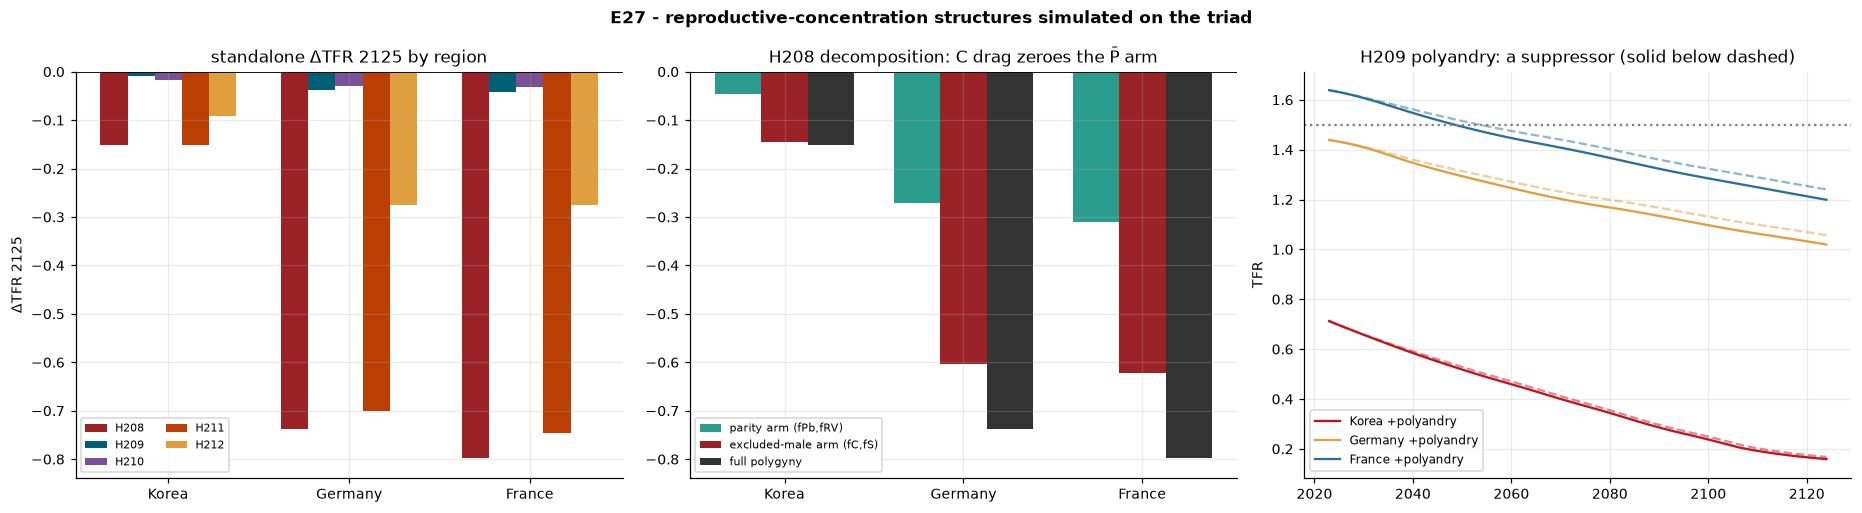

nb21_concentration_sim.png written

In [5]:
sim={L["id"]:{reg:seldon(reg,force_of(L)) for reg in TRIAD} for L in LEV}
def meandt(i): return float(np.mean([sim[i][r]["dtfr"] for r in TRIAD]))
tbl=Table(title="E27 - concentration structures on the triad (ΔTFR 2125 / fate)",header_style="bold cyan")
for c in ["hypothesis","claim"]+TRIAD+["mean"]: tbl.add_column(c)
for L in LEV:
    tbl.add_row(L["id"],L["expect"],*[f"{sim[L['id']][r]['dtfr']:+.3f} {sim[L['id']][r]['fate']}" for r in TRIAD],f"{meandt(L['id']):+.3f}")
rprint(tbl)

# decomposition of H208 polygyny: parity arm vs coupling arm vs full
pol=[L for L in LEV if L["id"]=="H208"][0]
arm_pb=dict(f={k:v for k,v in pol["f"].items() if k in("fPb","fRV")},mag=pol["mag"],d=10)
arm_c =dict(f={k:v for k,v in pol["f"].items() if k in("fC","fS")}, mag=pol["mag"],d=10)
dec={r:dict(pb=seldon(r,force_of(arm_pb))["dtfr"],c=seldon(r,force_of(arm_c))["dtfr"],full=sim["H208"][r]["dtfr"]) for r in TRIAD}

fig,ax=plt.subplots(1,3,figsize=(17,4.7)); fig.suptitle("E27 - reproductive-concentration structures simulated on the triad",fontweight="bold")
ids=[L["id"] for L in LEV]; x=np.arange(len(TRIAD)); w=0.15
cols={"H208":"#9b2226","H209":"#005f73","H210":"#7a5195","H211":"#bb3e03","H212":"#e09f3e"}
for k,i in enumerate(ids):
    ax[0].bar(x+(k-2)*w,[sim[i][r]["dtfr"] for r in TRIAD],w,label=i,color=cols[i])
ax[0].axhline(0,c="k",lw=0.6); ax[0].set(title="standalone ΔTFR 2125 by region",xticks=x); ax[0].set_xticklabels(TRIAD); ax[0].legend(fontsize=7,ncol=2); ax[0].set_ylabel("ΔTFR 2125")
xb=np.arange(len(TRIAD)); w2=0.26
ax[1].bar(xb-w2,[dec[r]["pb"] for r in TRIAD],w2,label="parity arm (fPb,fRV)",color="#2a9d8f")
ax[1].bar(xb,    [dec[r]["c"]  for r in TRIAD],w2,label="excluded-male arm (fC,fS)",color="#9b2226")
ax[1].bar(xb+w2,[dec[r]["full"] for r in TRIAD],w2,label="full polygyny",color="#333")
ax[1].axhline(0,c="k",lw=0.6); ax[1].set(title="H208 decomposition: C drag zeroes the P̄ arm",xticks=xb); ax[1].set_xticklabels(TRIAD); ax[1].legend(fontsize=7)
yr=np.arange(2023,2125)
for r,c in zip(TRIAD,["#c1121f","#e09f3e","#2a6f97"]):
    ax[2].plot(yr,BASE[r]["TFR"],ls="--",c=c,alpha=0.5)
    ax[2].plot(yr,sim["H209"][r]["traj"]["TFR"],c=c,label=f"{r} +polyandry")
ax[2].axhline(1.5,ls=":",c="grey"); ax[2].set(title="H209 polyandry: a suppressor (solid below dashed)",ylabel="TFR"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb21_concentration_sim.png",bbox_inches="tight"); plt.show()
rprint("[green]nb21_concentration_sim.png written[/green]")

## Verdicts

Claim-direction-aware: a lever that ASSERTS it raises fertility (`expect=up`) is REFUTED if it delivers a
material decline; the polyandry hypothesis ASSERTS suppression (`expect=down`) and is SUPPORTED if the model
robustly suppresses. This is how a controversial arc earns honest verdicts - the model confirms the
sex-ratio pivot the campaign already uses.

In [6]:
def vlabel(L):
    dt=meandt(L["id"]); exp=L["expect"]
    if exp=="down":  return "SUPPORTED" if dt<=-0.03 else ("PARTIAL" if dt<-0.005 else "REFUTED")
    if exp=="drag":  return "PARTIAL"  if dt<-0.005 else "REFUTED"
    # expect up: claims to raise fertility
    if dt>=0.05: return "SUPPORTED"
    if dt<=-0.02: return "REFUTED"
    return "PARTIAL"
claims={"H208":"polygyny raises aggregate fertility (a collapse lever)",
        "H209":"polyandry SUPPRESSES aggregate fertility (a population brake)",
        "H210":"mating-market skew drags coupling and delays partnering",
        "H211":"state sanction of polygyny manufactures the missing quantum",
        "H212":"media-normalising the structure raises fertility"}
ev={"H208":lambda:f"mean ΔTFR {meandt('H208'):+.3f}; decomposition shows the excluded-male C arm ({np.mean([dec[r]['c'] for r in TRIAD]):+.3f}) swamps the parity arm ({np.mean([dec[r]['pb'] for r in TRIAD]):+.3f}) - a double loss; Sahel high-TFR is development-confounded",
      "H209":lambda:f"mean ΔTFR {meandt('H209'):+.3f}; per-woman parity intact but female childlessness up (surplus unmarried women, Goldstein 1976) - the one mechanism that reliably moves TFR moves it DOWN, a population brake not a lever (wrong direction for collapse)",
      "H210":lambda:f"mean ΔTFR {meandt('H210'):+.3f}; a modest, self-correcting C drag plus tempo delay, but unquantified in the literature (thin parameter)",
      "H211":lambda:f"mean ΔTFR {meandt('H211'):+.3f}; legitimacy+subsidy entrench the externality rather than reverse it - sanction changes magnitude not sign, development-confounded",
      "H212":lambda:f"mean ΔTFR {meandt('H212'):+.3f}; pure N forcing with no material channel plus the incel-media C drag; media diffuses small-family ideals - cheap talk reverting under N hysteresis"}
V=[dict(id=f"E27-{L['id']}",claim=claims[L["id"]],evidence=ev[L["id"]](),verdict=vlabel(L)) for L in LEV]
(REPORTS/"nb21_e27_verdicts.json").write_text(json.dumps(V,indent=2))
with open(REPORTS/"nb21_concentration_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","name","claim_dir","cost","mean_dTFR","fate_korea","verdict"])
    for L in LEV:
        i=L["id"]; vd=[v for v in V if v["id"]==f"E27-{i}"][0]["verdict"]
        w.writerow([i,L["name"],L["expect"],cost(L),round(meandt(i),3),sim[i]["Korea"]["fate"],vd])
tbl=Table(title="E27 verdicts",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in V: tbl.add_row(v["id"],v["verdict"],v["evidence"])
rprint(tbl)
counts={}
for v in V: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E27 reproductive concentration, model-as-judge: {counts}. The arc confirms the sex-ratio pivot - the "
             "excluded-sex externality on C is the binding term. Polygyny is REFUTED as a lever (per-wife parity down AND "
             "the excluded-male C drag swamps it - a double loss under the multiplicative form); polyandry is a SUPPRESSOR "
             "(the one structure that reliably moves TFR moves it DOWN - wrong direction for collapse); hypergamy skew is a PARTIAL, unquantified C drag; state sanction "
             "entrenches rather than reverses; media-normalisation is cheap talk. No concentration structure lifts TFR in a "
             "developed low-fertility society net of the sex-ratio externality. Campaign total -> 237.",
             title="[bold]batch E27[/bold]",border_style="green"))

                                                   E27 verdicts                                                    
┏━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict ┃ evidence                                                                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E27-H208 │ REFUTED │ mean ΔTFR -0.562; decomposition shows the excluded-male C arm (-0.457) swamps the parity   │
│          │         │ arm (-0.209) - a double loss; Sahel high-TFR is development-confounded                     │
│ E27-H209 │ PARTIAL │ mean ΔTFR -0.029; per-woman parity intact but female childlessness up (surplus unmarried   │
│          │         │ women, Goldstein 1976) - the one mechanism that reliably moves TFR moves it DOWN, a        │
│          │         │ population brake not a lever (wrong direction for collapse)                                │
│ E27-H210 │ PARTIAL │ mean ΔTFR -0.026; a modest, self-correcting C drag plus tempo delay, but unquantified in   │
│          │         │ the literature (thin parameter)                                                            │
│ E27-H211 │ REFUTED │ mean ΔTFR -0.532; legitimacy+subsidy entrench the externality rather than reverse it -     │
│          │         │ sanction changes magnitude not sign, development-confounded                                │
│ E27-H212 │ REFUTED │ mean ΔTFR -0.214; pure N forcing with no material channel plus the incel-media C drag;     │
│          │         │ media diffuses small-family ideals - cheap talk reverting under N hysteresis               │
└──────────┴─────────┴────────────────────────────────────────────────────────────────────────────────────────────┘

╭─────────────────────────────────────────────────── batch E27 ───────────────────────────────────────────────────╮
│ E27 reproductive concentration, model-as-judge: {'REFUTED': 3, 'PARTIAL': 2}. The arc confirms the sex-ratio    │
│ pivot - the excluded-sex externality on C is the binding term. Polygyny is REFUTED as a lever (per-wife parity  │
│ down AND the excluded-male C drag swamps it - a double loss under the multiplicative form); polyandry is a      │
│ SUPPRESSOR (the one structure that reliably moves TFR moves it DOWN - wrong direction for collapse); hypergamy  │
│ skew is a PARTIAL, unquantified C drag; state sanction entrenches rather than reverses; media-normalisation is  │
│ cheap talk. No concentration structure lifts TFR in a developed low-fertility society net of the sex-ratio      │
│ externality. Campaign total -> 237.                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯